# Chebyshev Policies and the Mountain Car Problem: Reinforcement Learning for Low-dimensional Control Tasks
## PPO utilizing Chebyshev polynomial basis  

Can a more sophisticated Algorithm even boost results?  
As PPO is one of the go-to policy gradient methods, we implement Chebyshev approximators for use with the Stable Baselines3 framework to utilize its PPO implementation.  

Version 1.0   
Date: 2026-01-29   
Current version: hannes.unger@fh-salzburg.ac.at    

In [ ]:
import os
import time
import numpy as np
import multiprocessing as mp
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

from polyagents.polynomial_policies import PolynomialPPOPolicy
from utils import exp_run, plot

from pickleshare import PickleShareDB
db = PickleShareDB('./picklesharedb')

tensorboard_log_dir = "./tensorboard_logs/"
os.makedirs(tensorboard_log_dir, exist_ok=True)

%load_ext autoreload
%autoreload 2

## Training

In [2]:
env_name = "MountainCarContinuous-v0"
tensorboard_dir = tensorboard_log_dir + "ppo_mountaincarcontinuous"
## Hyperparameters determined for CH-PPO
learning_rate = 0.001 # default 0.0003
degree=3
n_steps = 2048 # default = 2048
batch_size = 1048 # default = 64
n_epochs = 2 # default = 10
clip_range = 0.4 # default = 0.2
clip_range_vf = 0.4 # default = None
use_fixed_std_schedule = False 

n_timesteps = 70_000

num_policies = 20
name_prefix_chebyshev = 'mountaincar_ch-ppo_'
seed = 0
num_cores=mp.cpu_count()

params = {'algo': 'ppo', 'learning_rate': learning_rate, 'steps': n_timesteps, 'env_name': env_name, 'tensorboard_log_dir': tensorboard_dir, 'name': name_prefix_chebyshev, 'seed': seed,          
          'clip_range': clip_range, 'clip_range_vf': clip_range_vf, 'n_steps': n_steps, 'n_epochs': n_epochs, 'batch_size': batch_size, 'policy_kwargs':dict(degree=degree, use_fixed_std_schedule=use_fixed_std_schedule)}

In [77]:
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=params, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)

In [ ]:
start = time.time()
with mp.Pool(processes=num_cores) as pool:
    results = pool.map(exp_run.run_sb3_polyagent_training, args)

# Permanently store results
db['mountaincar_sb3_chebyshev_ppo_20251220'] = results
print(f'Execution took {time.time()-start:.0f} seconds')

## Evaluation

As for our plot in the paper comparing SOTA agents (see below), we sample 100 equidistand deterministic starting points over the interval [-0.4, -0.6], covering the entire initialization range. In the picture below, the best agent by mean reward is depicted in the context of the SOTA agent comparison of our paper.

In [ ]:
xs = np.linspace(-0.6, -0.4, 100)
chebyshev_results = db['mountaincar_sb3_chebyshev_ppo_20251220']

chebyshev_eval_results = []

for c in chebyshev_results:
    rewards = []
    for x in xs:
        model, eval_env = exp_run.get_sb3_polynomial_model_and_eval_env(basis='chebyshev', env_name=env_name, coeffs=c[-1], algo='ppo')
        rewards.append(exp_run.run_sb3_model(model, eval_env, options={'low': x, 'high': x})[0])
    chebyshev_eval_results.append([np.mean(rewards), np.std(rewards), np.min(rewards), np.max(rewards)])

db['mountaincar_chebyshev_ppo_eval_results_20251220'] = chebyshev_eval_results

In [88]:
chebyshev_training_results = db['mountaincar_sb3_chebyshev_ppo_20251220']
chebyshev_eval_results = db['mountaincar_chebyshev_ppo_eval_results_20251220']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


MountainCarContinuous-v0: Top evaluation results after training
Rank   Model Name                Reward    
------ ------------------------- ----------
1      mountaincar_ch-ppo__20260111_2008_41_632429 98.0954    0       
2      mountaincar_ch-ppo__20260111_2008_39_867103 97.1726    0       
3      mountaincar_ch-ppo__20260111_2008_41_331971 96.6680    0       
4      mountaincar_ch-ppo__20260111_2008_41_163907 96.6203    0       
5      mountaincar_ch-ppo__20260111_2008_40_425446 96.1812    0       

            Combined Mean Reward of Top Results             
Mean reward: 96.9475


In [5]:
chebyshev_training_results = db['mountaincar_sb3_chebyshev_ppo_20251220']
best_agent_name = 'mountaincar_ch-ppo__20260111_2008_41_632429'
best_agent = next(((i, row) for i, row in enumerate(chebyshev_training_results) if row[0] == best_agent_name), None)
best_agent_coeffs = best_agent[-1][-1]
best_agent_index = best_agent[0]
db['mountaincar_ch_ppo_best_agent_params'] = best_agent_coeffs

The resulting PPO policy is smoother than the ARS one, closer to the CH-3 REINFORCE result.  
Also the value and sigma function result shows little oscillating behaviour.  

Using cpu device


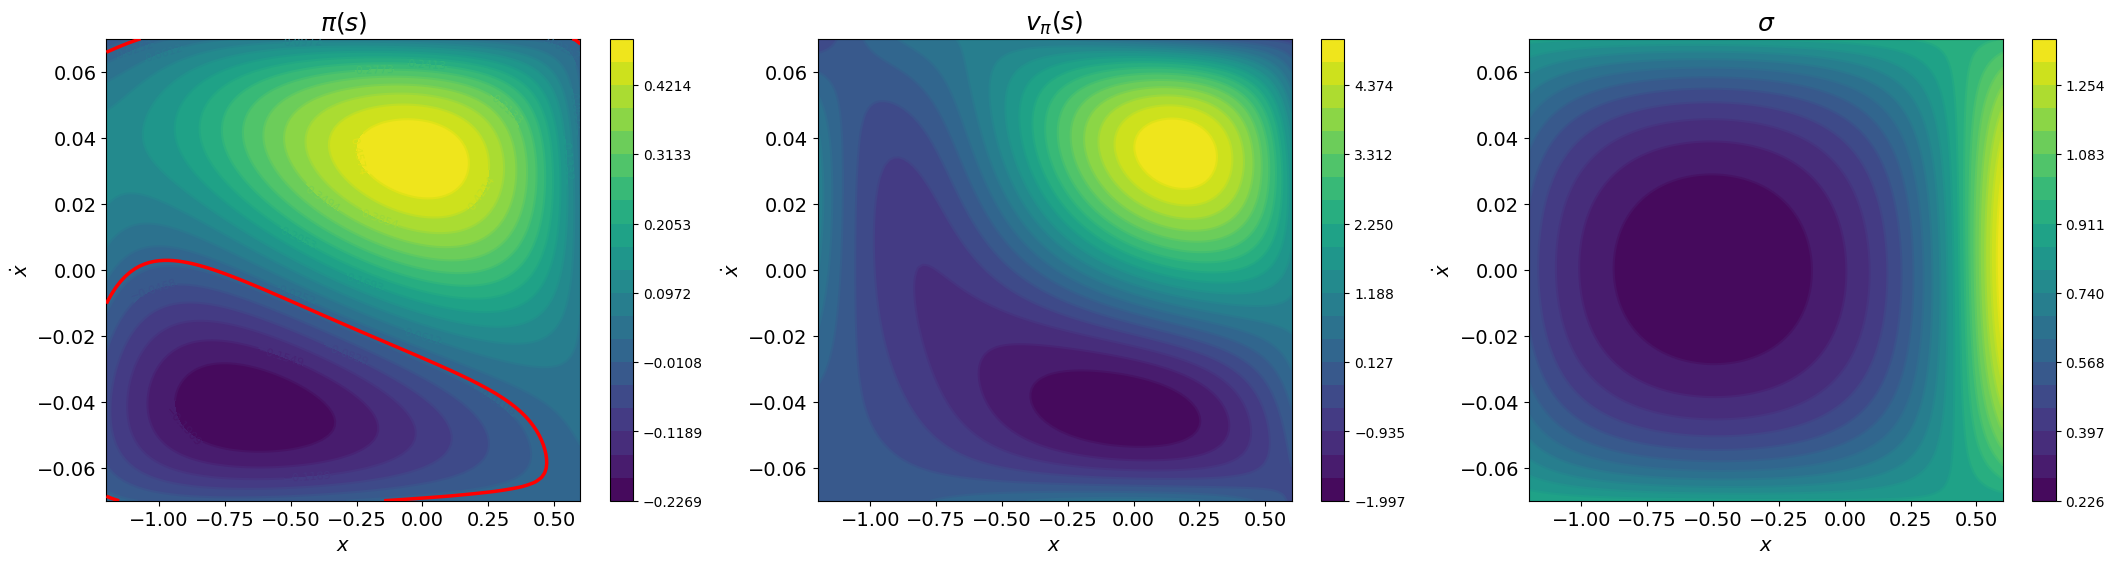

In [92]:
model, eval_env = exp_run.get_sb3_polynomial_model_and_eval_env(basis='chebyshev', env_name=env_name, coeffs=best_agent_coeffs, algo='ppo')

plot.plot_sb3_chebyshev_mountaincar_policy(model, algo='ppo')

In [93]:
chebyshev_eval_results[best_agent_index]

[np.float32(98.09543),
 np.float32(0.22167431),
 np.float32(97.61245),
 np.float32(98.41863)]

In [ ]:
chebyshev_ars_training_results = db['mountaincar_sb3_chebyshev_ars_20251105']
chebyshev_ars_eval_results = db['mountaincar_chebyshev_ars_eval_results_20251105']
plot.print_eval_results([chebyshev_ars_eval_results], [chebyshev_ars_training_results], env_name=env_name)


MountainCarContinuous-v0: Top evaluation results after training
Rank   Model Name                Reward    
------ ------------------------- ----------
1      mountaincar_ch-ars__20251106_0946_17_237349 98.9503    0       
2      mountaincar_ch-ars__20251106_0948_17_521527 98.8624    0       
3      mountaincar_ch-ars__20251106_0946_17_516748 98.7457    0       
4      mountaincar_ch-ars__20251106_0946_16_111891 98.6733    0       
5      mountaincar_ch-ars__20251106_0948_8_061488 98.6386    0       

            Combined Mean Reward of Top Results             
Mean reward: 98.7740


In [ ]:
chebyshev_ars_training_results = db['mountaincar_sb3_chebyshev_ars_20251105']
best_agent_name_ars = 'mountaincar_ch-ars__20251106_0946_17_237349'
best_agent_ars = next(((i, row) for i, row in enumerate(chebyshev_ars_training_results) if row[0] == best_agent_name_ars), None)
best_agent_coeffs_ars = best_agent_ars[-1][-1]
best_agent_index_ars = best_agent_ars[0]

Text(0.5, 1.1, 'MountainCarContinuous-v0\nMin, mean and max reward, episode length and velocity at target for different trained agents\nLeft wall at $x=-1.2$, $100$ evenly spaced starting positions over the interval $x_0 \\in [-0.6, -0.4]$\n$C_1=$4.3346, $C_2=$4.8358')

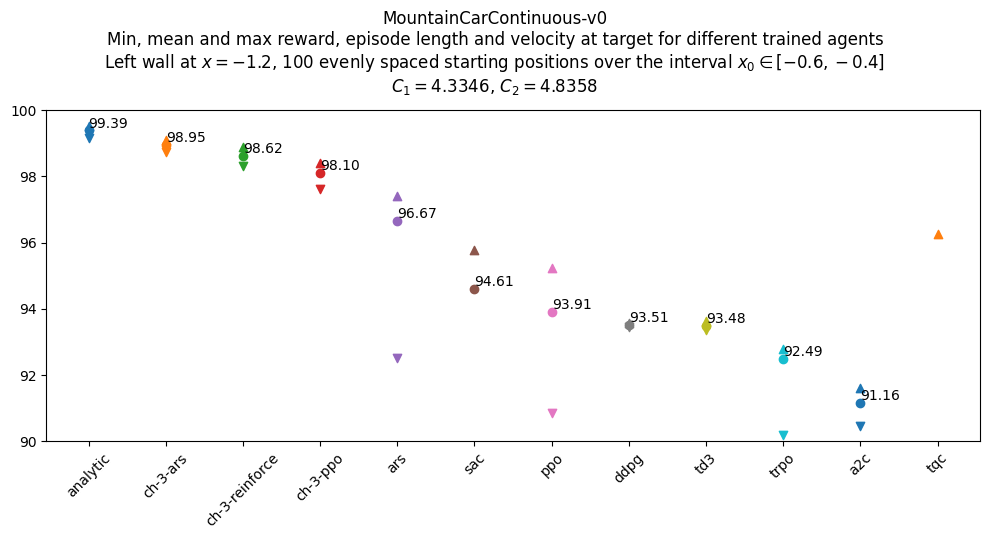

In [94]:
import matplotlib.gridspec as gridspec

results = db['huggingface_single_episode_results']
results_analytic = db['analytic_single_episode_results']
results_chebyshev3= db['chebyshev_single_episode_results'] 
results_chebyshev_ars = db['mountaincar_chebyshev_ars_eval_results_20251105']
results_chebyshev_ppo = db['mountaincar_chebyshev_ppo_eval_results_20251220']
r_analytic = [a[1] for a in results_analytic]
target_velocities_analytic = [a[3] for a in results_analytic]
steps_analytic = [len(a[4]) for a in results_analytic]

r_chebyshev3 = [a[0] for a in results_chebyshev3]
target_velocities_chebyshev3 = [a[2][-1][1] for a in results_chebyshev3]
steps_chebyshev3 = [len(a[2]) for a in results_chebyshev3]

chebyshev_ppo_episode_reward = [results_chebyshev_ppo[best_agent_index][2], results_chebyshev_ppo[best_agent_index][0], results_chebyshev_ppo[best_agent_index][-1]]
chebyshev_ars_episode_reward = [results_chebyshev_ars[best_agent_index_ars][2], results_chebyshev_ars[best_agent_index_ars][0], results_chebyshev_ars[best_agent_index_ars][-1]]
chebyshev3_episode_reward = [np.min([r for r in r_chebyshev3]), np.mean([r for r in r_chebyshev3]), np.max([r for r in r_chebyshev3])]
analytic_episode_reward = [np.min([r for r in r_analytic]), np.mean([r for r in r_analytic]), np.max([r for r in r_analytic])]
ars_episode_reward = [np.min([r[0] for r in results[7]]), np.mean([r[0] for r in results[7]]), np.max([r[0] for r in results[7]])]
ddpg_episode_reward = [np.min([r[0] for r in results[6]]), np.mean([r[0] for r in results[6]]), np.max([r[0] for r in results[6]])]
a2c_episode_reward = [np.min([r[0] for r in results[5]]), np.mean([r[0] for r in results[5]]), np.max([r[0] for r in results[5]])]
trpo_episode_reward = [np.min([r[0] for r in results[4]]), np.mean([r[0] for r in results[4]]), np.max([r[0] for r in results[4]])]
td3_episode_reward = [np.min([r[0] for r in results[3]]), np.mean([r[0] for r in results[3]]), np.max([r[0] for r in results[3]])]
sac_episode_reward = [np.min([r[0] for r in results[2]]), np.mean([r[0] for r in results[2]]), np.max([r[0] for r in results[2]])]
tqc_episode_reward = [np.min([r[0] for r in results[1]]), np.mean([r[0] for r in results[1]]), np.max([r[0] for r in results[1]])]
ppo_episode_reward = [np.min([r[0] for r in results[0]]), np.mean([r[0] for r in results[0]]), np.max([r[0] for r in results[0]])]

data = {'ars': ars_episode_reward, 'ddpg': ddpg_episode_reward, 'a2c': a2c_episode_reward, 'trpo': trpo_episode_reward, 'td3': td3_episode_reward, 'sac': sac_episode_reward, 'tqc': tqc_episode_reward, 'ppo': ppo_episode_reward, 'analytic': analytic_episode_reward, 'ch-3-reinforce': chebyshev3_episode_reward, 'ch-3-ars': chebyshev_ars_episode_reward, 'ch-3-ppo': chebyshev_ppo_episode_reward}
sorted_data = dict(sorted(data.items(), key=lambda item: item[1][1], reverse=True)) # sort by mean reward

fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, :])  # Span all columns

# Plt1: Extract names and values
names = list(sorted_data.keys())
values = list(sorted_data.values())

# Create a consistent color mapping for names
unique_names = list(sorted_data.keys())  # Start with names from data1
colors = [plt.cm.tab10(i % 10) for i in range(len(unique_names))]
color_map = {name: colors[i] for i, name in enumerate(unique_names)}

# # Include new names from the second dictionary and assign new colors if needed
# for name in len_data.keys():
#     if name not in color_map:
#         color_map[name] = plt.cm.tab10(len(color_map) % 10)  # Cycle through colors

for i, (name, value) in enumerate(sorted_data.items()):
    ax1.scatter(i, value[0], color=color_map[name], label=name, marker='v')
    ax1.scatter(i, value[1], color=color_map[name], label=name, marker='o')
    ax1.scatter(i, value[2], color=color_map[name], label=name, marker='^')
    # Add the value next to the point
    if value[1] > 90:
        #ax1.text(i, value[0], f"{value[0]:.2f}", fontsize=10, verticalalignment='bottom')
        ax1.text(i, value[1], f"{value[1]:.2f}", fontsize=10, verticalalignment='bottom')
        #ax1.text(i, value[2], f"{value[2]:.2f}", fontsize=10, verticalalignment='bottom')

ax1.set_xticks(range(len(names)), names, fontsize=10, rotation=45)
#ax1.set_title("Episode Reward")
ax1.set_ylim([90,100])



fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.suptitle('MountainCarContinuous-v0\n'r'Min, mean and max reward, episode length and velocity at target for different trained agents' '\n' r'Left wall at $x=-1.2$, $100$ evenly spaced starting positions over the interval $x_0 \in [-0.6, -0.4]$' '\n'  r'$C_1=$' f'{db["c1_max_1000"]:.4f}, ' r'$C_2=$' f'{db["c2_optimum"]:.4f}', y=1.1)